# Chapter 56: Reinforcement Learning for Game Competitions

**At what size of intermediate reward does a learner stop trying to win, and does the shaped return reveal it?**

Game rewards are sparse, so competitors add intermediate rewards for resources, territory or survival. If an intermediate reward can be collected repeatedly, a larger one pays more than winning, and a policy chosen by its shaped return stops winning.

*Constructed game; the bonus size at which winning stops depends on the corridor length, the discount and the slip rate. The learned and the value-iteration policies agree here because the learner explores enough, which holds for this small game only.*

## The experiment

A constructed corridor game: 14 cells, the agent starts at the left end and wins (+1) by reaching the right end within 30 steps; each move slips with probability 0.1. A resource cell near the start pays a bonus for every fresh arrival, so it can be farmed by stepping off and on. Tabular Q-learning with optimistic initial values runs for 800 games per learner, 8 learners per setting. Four policies are compared at the control's bonus: learned on the true reward only, learned with the bonus, learned with a potential-based progress reward of the same weight, and the best policy for the bonus reward found by value iteration. Each is scored on 200 fresh games for win rate and for shaped return (win plus bonuses).

In [1]:
import random
from functools import lru_cache

import numpy as np

from kaggle_companion.activities._common import clean

SEED = 56
CELLS, MINE, STEPS = 14, 3, 30    # corridor of 14 cells, a resource cell at 3, the goal at the far end, 30 steps to win
SLIP, GAMMA = 0.1, 0.97           # a move slips (reverses) 10% of the time; discount for the learner
EPISODES, LEARNERS, EVAL_GAMES = 800, 8, 200
ALPHA, EPSILON = 0.2, 0.1
OPTIMISM = 1.0                    # optimistic initial action values make the learner try every action before settling


def move(state, action, rng):
    """One step of the corridor game: action 1 is right, 0 is left; the move slips with probability SLIP."""
    if rng.random() < SLIP:
        action = 1 - action
    return min(CELLS - 1, max(0, state + (1 if action else -1)))


def reward(state, nxt, bonus, kind):
    """True reward (+1 for winning) plus shaping. 'bonus' pays for each fresh arrival at the resource cell;
    'potential' pays the change in a progress potential (gamma * phi(next) - phi(state)), which cannot change the best policy."""
    done = nxt == CELLS - 1
    r = 1.0 if done else 0.0
    if kind == "bonus" and nxt == MINE and state != MINE:
        r += bonus
    if kind == "potential":
        phi = lambda s: bonus * s / (CELLS - 1)
        r += GAMMA * (0.0 if done else phi(nxt)) - phi(state)
    return r


def train(bonus, kind, seed):
    """Tabular Q-learning with epsilon-greedy exploration; returns the greedy policy (one action per cell)."""
    rng = random.Random(seed)
    q = [[OPTIMISM, OPTIMISM] for _ in range(CELLS)]
    for _ in range(EPISODES):
        state = 0
        for _ in range(STEPS):
            if rng.random() < EPSILON:
                action = rng.randrange(2)
            else:
                action = 0 if q[state][0] > q[state][1] else 1 if q[state][1] > q[state][0] else rng.randrange(2)
            nxt = move(state, action, rng)
            done = nxt == CELLS - 1
            target = reward(state, nxt, bonus, kind) + (0.0 if done else GAMMA * max(q[nxt]))
            q[state][action] += ALPHA * (target - q[state][action])
            state = nxt
            if done:
                break
    return [0 if row[0] > row[1] else 1 for row in q]


def optimal_policy(bonus):
    """Value iteration on the same game with the bonus reward: the best any learner could settle on."""
    q = np.zeros((CELLS, 2))
    for _ in range(600):
        for s in range(CELLS - 1):
            for a in (0, 1):
                total = 0.0
                for actual, p in ((a, 1 - SLIP), (1 - a, SLIP)):
                    nxt = min(CELLS - 1, max(0, s + (1 if actual else -1)))
                    done = nxt == CELLS - 1
                    total += p * (reward(s, nxt, bonus, "bonus") + (0.0 if done else GAMMA * q[nxt].max()))
                q[s, a] = total
    return [int(q[s, 1] >= q[s, 0]) for s in range(CELLS)]


def play(policy, bonus, rng):
    """Mean win rate and mean shaped return (win plus bonus per resource arrival) of a policy over fresh games."""
    wins, shaped = 0, 0.0
    for _ in range(EVAL_GAMES):
        state = 0
        for _ in range(STEPS):
            nxt = move(state, policy[state], rng)
            shaped += reward(state, nxt, bonus, "bonus")
            state = nxt
            if state == CELLS - 1:
                wins += 1
                break
    return wins / EVAL_GAMES, shaped / EVAL_GAMES


@lru_cache(maxsize=None)
def sparse_policies(seed):
    """The learners trained on the true reward only; they do not depend on the bonus, so they are trained once."""
    return [train(0.0, "bonus", seed * 100 + i) for i in range(LEARNERS)]


def run(bonus):
    rng = random.Random(SEED)
    sparse = [play(p, bonus, rng) for p in sparse_policies(SEED)]
    shaped = [play(train(bonus, "bonus", SEED * 100 + 50 + i), bonus, rng) for i in range(LEARNERS)]
    potential = [play(train(bonus, "potential", SEED * 100 + 80 + i), bonus, rng) for i in range(LEARNERS)]
    best = play(optimal_policy(bonus), bonus, rng)
    column = lambda rows, k: [row[k] for row in rows]
    return clean({
        "bonus": bonus,
        "win": {"sparse": float(np.mean(column(sparse, 0))), "bonus": float(np.mean(column(shaped, 0))),
                "potential": float(np.mean(column(potential, 0))), "optimal": best[0]},
        "shaped_return": {"sparse": float(np.mean(column(sparse, 1))), "bonus": float(np.mean(column(shaped, 1))),
                          "optimal": best[1]},
        "per_learner_win": {"sparse": column(sparse, 0), "bonus": column(shaped, 0), "potential": column(potential, 0)},
        "learners": LEARNERS, "games": EVAL_GAMES,
    })


## Measure it across the control

The control is **reward per fresh arrival at the resource cell (a win pays 1)**. Each value below runs the whole experiment from the generator up.

In [2]:
import pandas as pd
from kaggle_companion.activities.ch56 import explain

VALUES = [0.02, 0.05, 0.1, 0.5]
results = {value: run(value) for value in VALUES}
table = pd.DataFrame({str(v): explain(results[v], v)['metrics'] for v in VALUES})
print(table.to_string())

                                 0.02  0.05   0.1   0.5
Win rate, true reward only       100%  100%  100%  100%
Win rate, resource bonus         100%   31%    0%    0%
Win rate, potential-based        100%  100%  100%  100%
Shaped return, true reward only  1.02  1.06  1.13  1.64
Shaped return, resource bonus    1.02  0.79  1.23  6.17


## Look at it

The figure shows the default setting, reward per fresh arrival at the resource cell (a win pays 1) = 0.1.

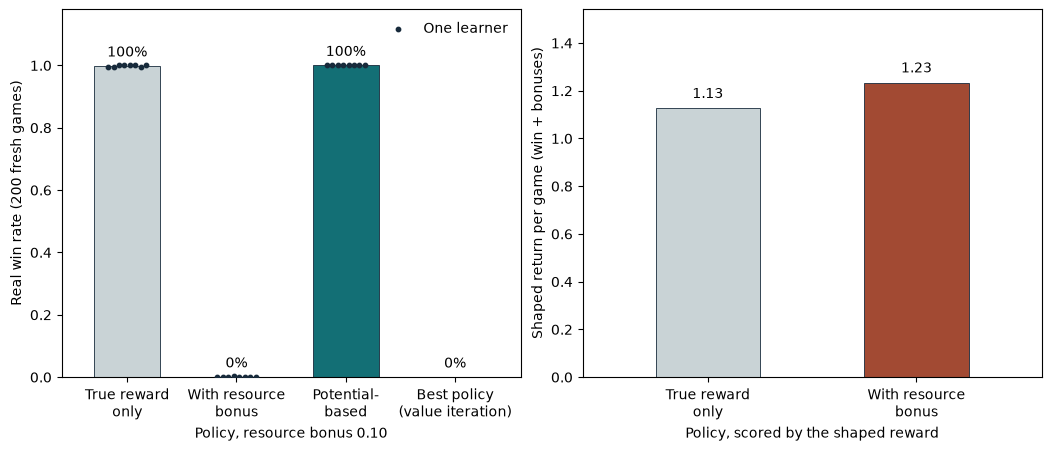

In [3]:
import matplotlib.pyplot as plt
from kaggle_companion.activities.ch56 import draw, NCOLS, HEIGHT

DEFAULT = 0.1
fig, axes = plt.subplots(1, NCOLS, figsize=(6.6 if NCOLS == 1 else 10.4, HEIGHT), layout='constrained')
draw(axes, results[DEFAULT], DEFAULT)
plt.show()

## What the result says

With a bonus of 0.10 per arrival, the learner trained on the true reward wins 100% of games and the one trained with the bonus 0%, so 1.00 - 0.00 = 1.00 of the wins are lost to the bonus. The potential-based reward of the same weight wins 100% and the best policy for the bonus reward 0%. In shaped return the bonus-trained policy scores 1.23 and the true-reward policy 1.13, a difference of 0.10 in favour of the policy that stopped winning.

- Wins lost to the bonus: 1.00 - 0.00 = 1.00.
- Shaped return, bonus-trained minus true-reward policy: 1.23 - 1.13 = +0.10.
- Potential-based learner win rate: 100%.
- Best policy for the bonus reward: wins 0% with shaped return 1.24.

## Apply this to your competition

- Evaluate every checkpoint on the real win rate against the declared opponents and seeds, and keep the shaped return as a training diagnostic only.
- Make intermediate rewards pay once per event, or as a potential-based difference, so they cannot be farmed.
- Keep the weight of a shaping term small enough that the best policy for the shaped reward is still a winning policy.
- Check that exploration is not the problem before blaming the reward: a learner that never reaches the goal looks the same from outside.

Book location: Chapter 56, The Fundamental Challenge: Sparse Rewards, Long Horizons.

[Technical corrections](https://github.com/KarpelesPublishing/winning-kaggle-companion/blob/main/docs/errata.md)